# Random Forest Regression – Log Price Transformation

**Goal:** Train on `log(price)` instead of raw price to see if the model
performs better, especially on the stress test.

**Why log transformation?**

Price data is often **skewed** — most items cost 10–25 EUR but some cost 40+.
A raw price model treats a 10 EUR error the same whether the item costs
15 EUR or 50 EUR. But in reality:
- 10 EUR off on a 15 EUR product = 67% error (huge!)
- 10 EUR off on a 50 EUR product = 20% error (acceptable)

`log(price)` compresses the scale so the model learns **relative differences**
("30% more expensive") instead of **absolute differences** ("8 EUR more").
This often improves predictions on both cheap and expensive items.

**Workflow:**
1. Load data, explore the price distribution
2. Apply log transformation and compare distributions
3. Train/test split
4. Train Random Forest on log(price)
5. Convert predictions back to EUR and evaluate
6. Impute stress-test data and evaluate
7. Compare with all previous experiments


## Step 1 – Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load the Training Dataset

In [4]:
df = pd.read_csv("meat_price_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Price stats:")
print(df["price_eur_per_kg"].describe().round(2))


Shape: (1200, 9)
Price stats:
count    1200.00
mean       23.05
std         8.18
min         2.50
25%        16.88
50%        23.22
75%        29.54
max        43.33
Name: price_eur_per_kg, dtype: float64


## Step 3 – Why Log? Visualise the Price Distribution

We compare raw price vs log(price) to see the effect.

**`np.log1p(x)`** = log(1 + x) — safer than log(x) because it handles
zero values (log(0) is undefined, but log(1+0) = 0).

**`np.expm1(x)`** = exp(x) - 1 — the inverse function to convert back.


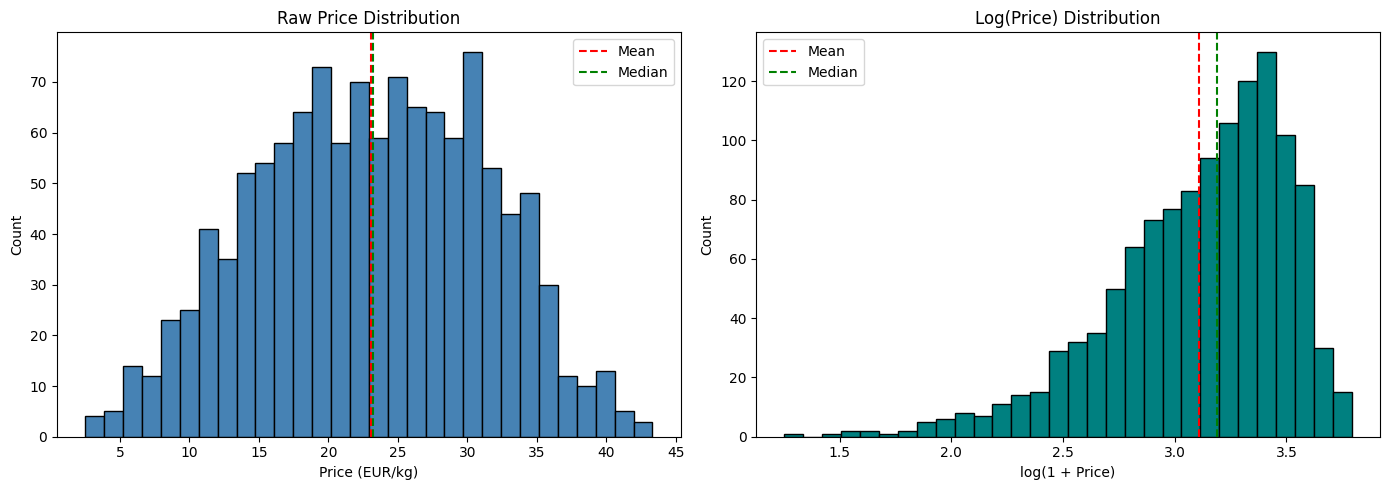

Raw price  — Mean: 23.05, Median: 23.23, Skew: -0.070
Log price  — Mean: 3.11, Median: 3.19, Skew: -1.027
If skew is closer to 0 after log, the transformation helped.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
axes[0].hist(df["price_eur_per_kg"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Raw Price Distribution")
axes[0].set_xlabel("Price (EUR/kg)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["price_eur_per_kg"].mean(), color="red", linestyle="--", label="Mean")
axes[0].axvline(df["price_eur_per_kg"].median(), color="green", linestyle="--", label="Median")
axes[0].legend()

# Log price
log_price = np.log1p(df["price_eur_per_kg"])
axes[1].hist(log_price, bins=30, color="teal", edgecolor="black")
axes[1].set_title("Log(Price) Distribution")
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Count")
axes[1].axvline(log_price.mean(), color="red", linestyle="--", label="Mean")
axes[1].axvline(log_price.median(), color="green", linestyle="--", label="Median")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Raw price  — Mean: {df['price_eur_per_kg'].mean():.2f}, Median: {df['price_eur_per_kg'].median():.2f}, Skew: {df['price_eur_per_kg'].skew():.3f}")
print(f"Log price  — Mean: {log_price.mean():.2f}, Median: {log_price.median():.2f}, Skew: {log_price.skew():.3f}")
print(f"If skew is closer to 0 after log, the transformation helped.")


## Step 4 – Apply Log Transformation

We transform the target **before** splitting, so both train and test
use log(price). After prediction, we convert back with `expm1()`.


In [6]:
target_col = "price_eur_per_kg"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y_raw = df[target_col]
y_log = np.log1p(y_raw)  # <-- log transform

print("Features:", feature_cols)
print(f"y_raw range: {y_raw.min():.2f} – {y_raw.max():.2f} EUR")
print(f"y_log range: {y_log.min():.2f} – {y_log.max():.2f}")


Features: ['meat_type', 'fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality']
y_raw range: 2.50 – 43.33 EUR
y_log range: 1.25 – 3.79


## Step 5 – Train / Test Split

In [7]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log,
    test_size=0.20,
    random_state=42,
)

# Keep raw test prices for evaluation in EUR
y_test_raw = np.expm1(y_test_log)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test  set: {X_test.shape[0]} rows")


Train set: 960 rows
Test  set: 240 rows


## Step 6 – Train the Random Forest on log(price)

The model now learns to predict log(price), not raw EUR.
Same baseline configuration as previous experiments.


In [8]:
rf_log = RandomForestRegressor(
    n_estimators=200,
    max_depth=7,
    random_state=42,
    n_jobs=-1,
)

rf_log.fit(X_train, y_train_log)

print("Model trained on log(price).")
print(f"Number of trees: {rf_log.n_estimators}")


Model trained on log(price).
Number of trees: 200


## Step 7 – Predict and Convert Back to EUR

**Critical step:** The model outputs log(price). We must convert back
with `np.expm1()` before calculating errors in EUR.




In [9]:
# Predict in log space
y_pred_log = rf_log.predict(X_test)

# Convert back to EUR
y_pred_eur = np.expm1(y_pred_log)

# Evaluate in EUR (real-world units)
mae  = mean_absolute_error(y_test_raw, y_pred_eur)
rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred_eur))
r2   = r2_score(y_test_raw, y_pred_eur)

print("=== Internal Test (EUR) ===")
print(f"MAE:  {mae:.2f} EUR")
print(f"RMSE: {rmse:.2f} EUR")
print(f"R²:   {r2:.4f}")
print(f"Mean price: {y_test_raw.mean():.2f} EUR")
print(f"Relative error: {mae / y_test_raw.mean() * 100:.1f}%")


=== Internal Test (EUR) ===
MAE:  1.80 EUR
RMSE: 2.24 EUR
R²:   0.9252
Mean price: 23.41 EUR
Relative error: 7.7%


## Step 8 – Also Evaluate in Log Space

R² in log space shows how well the model learned the transformed target.


In [10]:
r2_log = r2_score(y_test_log, y_pred_log)
mae_log = mean_absolute_error(y_test_log, y_pred_log)

print("=== Internal Test (Log Space) ===")
print(f"MAE (log):  {mae_log:.4f}")
print(f"R² (log):   {r2_log:.4f}")
print(f"Note: R² in log space can differ from R² in EUR space.")


=== Internal Test (Log Space) ===
MAE (log):  0.0872
R² (log):   0.9045
Note: R² in log space can differ from R² in EUR space.


## Step 9 – Actual vs Predicted Plots

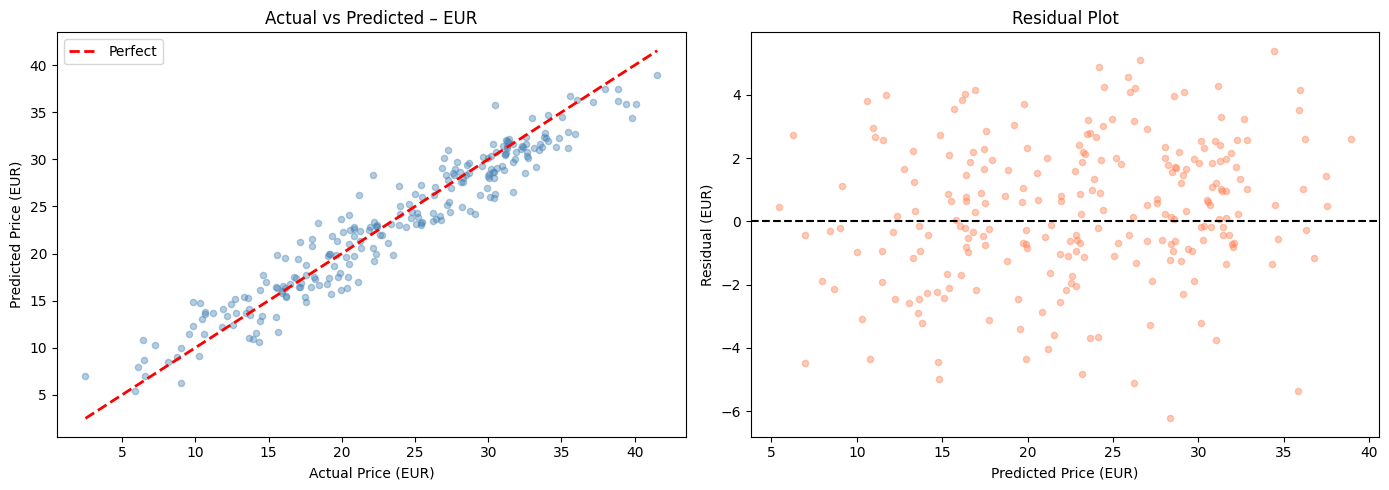

Mean residual: 0.32 EUR
Std  residual: 2.23 EUR


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted (EUR)
axes[0].scatter(y_test_raw, y_pred_eur, alpha=0.4, s=20, color="steelblue")
axes[0].plot([y_test_raw.min(), y_test_raw.max()],
             [y_test_raw.min(), y_test_raw.max()],
             color="red", linestyle="--", linewidth=2, label="Perfect")
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted – EUR")
axes[0].legend()

# Residuals
residuals = y_test_raw - y_pred_eur
axes[1].scatter(y_pred_eur, residuals, alpha=0.4, s=20, color="coral")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual (EUR)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f} EUR")
print(f"Std  residual: {residuals.std():.2f} EUR")


## Step 10 – Feature Importance

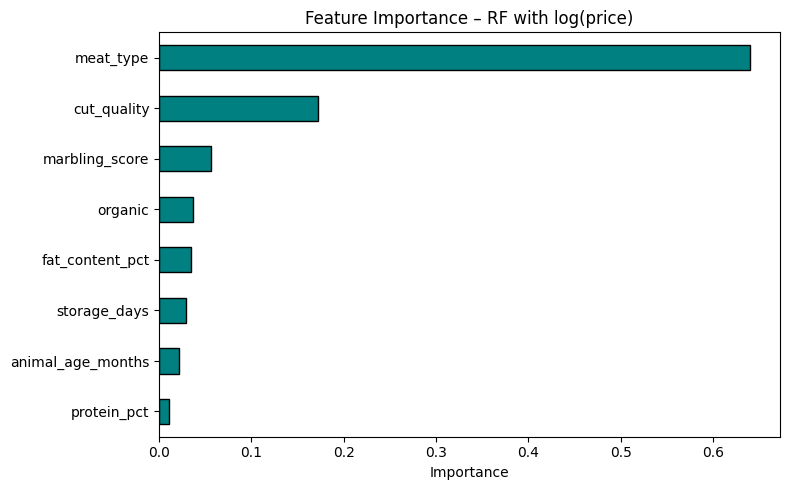

Importance values:
protein_pct          0.0108
animal_age_months    0.0217
storage_days         0.0288
fat_content_pct      0.0341
organic              0.0365
marbling_score       0.0558
cut_quality          0.1717
meat_type            0.6406
dtype: float64


In [12]:
importances = pd.Series(rf_log.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – RF with log(price)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))


## Step 11 – Load and Impute the Stress-Test Data

Using KNN imputation (fitted on training data) for better fills.


In [13]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print(f"Shape: {df_stress.shape}")
print(f"Missing values:{df_stress.isnull().sum()}")

X_stress = df_stress[feature_cols].copy()
y_stress_raw = df_stress[target_col].copy()

# KNN imputation fitted on training data
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputer.fit(X_train)

X_stress_filled = pd.DataFrame(
    knn_imputer.transform(X_stress),
    columns=feature_cols,
)

# Drop rows where target is NaN
valid_mask = y_stress_raw.notna()
X_stress_valid = X_stress_filled[valid_mask]
y_stress_valid = y_stress_raw[valid_mask]

print(f"Usable stress-test rows: {X_stress_valid.shape[0]} / {len(df_stress)}")
print(f"Missing after imputation: {X_stress_valid.isnull().sum().sum()}")


Shape: (100, 9)
Missing values:meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64
Usable stress-test rows: 91 / 100
Missing after imputation: 0


## Step 12 – Evaluate on the Stress-Test Data

Predict in log space, convert back to EUR, compare.


In [14]:
# Predict in log space
y_stress_pred_log = rf_log.predict(X_stress_valid)

# Convert back to EUR
y_stress_pred_eur = np.expm1(y_stress_pred_log)

# Evaluate in EUR
mae_s  = mean_absolute_error(y_stress_valid, y_stress_pred_eur)
rmse_s = np.sqrt(mean_squared_error(y_stress_valid, y_stress_pred_eur))
r2_s   = r2_score(y_stress_valid, y_stress_pred_eur)

print("=== Stress Test (EUR) ===")
print(f"MAE:  {mae_s:.2f} EUR")
print(f"RMSE: {rmse_s:.2f} EUR")
print(f"R²:   {r2_s:.4f}")
print(f"Mean price: {y_stress_valid.mean():.2f} EUR")
print(f"Relative error: {mae_s / y_stress_valid.mean() * 100:.1f}%")


=== Stress Test (EUR) ===
MAE:  8.80 EUR
RMSE: 11.27 EUR
R²:   -0.3161
Mean price: 29.97 EUR
Relative error: 29.4%


## Step 13 – Stress-Test Visualisation

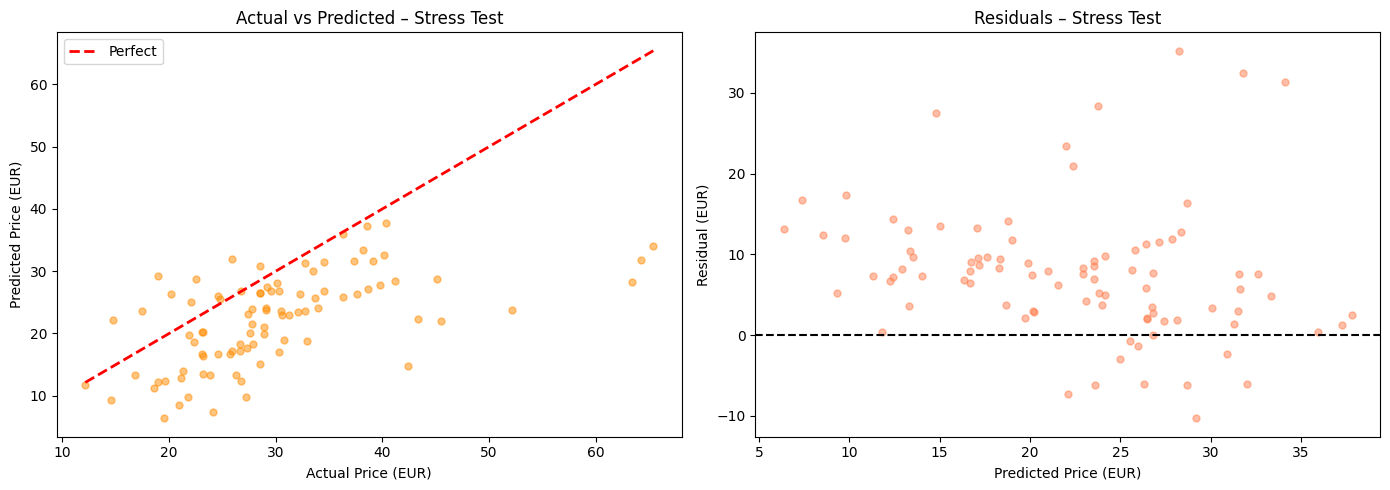

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_stress_valid, y_stress_pred_eur, alpha=0.5, s=25, color="darkorange")
axes[0].plot([y_stress_valid.min(), y_stress_valid.max()],
             [y_stress_valid.min(), y_stress_valid.max()],
             color="red", linestyle="--", linewidth=2, label="Perfect")
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted – Stress Test")
axes[0].legend()

residuals_s = y_stress_valid - y_stress_pred_eur
axes[1].scatter(y_stress_pred_eur, residuals_s, alpha=0.5, s=25, color="coral")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual (EUR)")
axes[1].set_title("Residuals – Stress Test")

plt.tight_layout()
plt.show()


## Step 14 – Full Comparison: All Experiments


In [16]:
print("=" * 75)
print("COMPLETE COMPARISON — All Experiments")
print("=" * 75)

comparison = pd.DataFrame({
    "Experiment": [
        "DT baseline (depth 7)",
        "DT GridSearchCV (4320 combos)",
        "RF baseline (raw price)",
        "RF GridSearch (raw price)",
        "RF + KNN imputation",
        "RF combined dataset",
        "RF log(price) (this notebook)",
    ],
    "MAE Test": [
        "2.38", "2.18", "1.80", "—", "1.80", "2.15",
        f"{mae:.2f}",
    ],
    "R² Test": [
        "0.8737", "0.8875", "0.9249", "0.9215", "0.9249", "0.8841",
        f"{r2:.4f}",
    ],
    "MAE Stress": [
        "8.59", "8.70", "8.68", "8.46", "8.64", "8.70",
        f"{mae_s:.2f}",
    ],
    "R² Stress": [
        "-0.2544", "-0.3108", "-0.3288", "-0.2711", "-0.2806", "-0.3082",
        f"{r2_s:.4f}",
    ],
})

print(comparison.to_string(index=False))

print("--- Done! ---")


COMPLETE COMPARISON — All Experiments
                   Experiment MAE Test R² Test MAE Stress R² Stress
        DT baseline (depth 7)     2.38  0.8737       8.59   -0.2544
DT GridSearchCV (4320 combos)     2.18  0.8875       8.70   -0.3108
      RF baseline (raw price)     1.80  0.9249       8.68   -0.3288
    RF GridSearch (raw price)        —  0.9215       8.46   -0.2711
          RF + KNN imputation     1.80  0.9249       8.64   -0.2806
          RF combined dataset     2.15  0.8841       8.70   -0.3082
RF log(price) (this notebook)     1.80  0.9252       8.80   -0.3161
--- Done! ---
